In [2]:
pip install moviepy

  Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl (7.0 MB)
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.2 MB ? eta -:--:--
    --------------------------------------- 0.5/31.2 MB 1.3 MB/s eta 0:00:24
   - -------------------------------------- 0.8/31.2 MB 1.4 MB/s eta 0:00:22
   - -------------------------------------- 1.0/31.2 MB 1.4 MB/s eta 0:00:22
   - -------------------------------------- 1.3/31.2 MB 1.5 MB/s eta 0:00:21
   -- ------------------------------------- 1.6/31.2 MB 1.4 MB/s eta 0:00:21
   -- ------------------------------------- 2.1/31.2 MB 1.5 MB/s eta 0:00:19
   --- ------------------------------------ 2.6/31.2 MB 1.6 MB/s eta 0:00:18
   --- ------------------------------------ 2.9/31.2 MB 1.6 MB/s eta 0:00:18
   ---- -------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
instagrapi 2.8.21 requires Pillow==12.2.0, but you have pillow 11.3.0 which is incompatible.


In [5]:
import cv2
import matplotlib.pyplot as plt

video_path = "WIN_20260613_21_37_32_Pro.mp4"

cap = cv2.自在VideoFileClip = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = total_frames / fps

print(f"Video loaded successfully!")
print(f"Total Duration: {duration:.2f} seconds")

Video loaded successfully!
Total Duration: 7.87 seconds


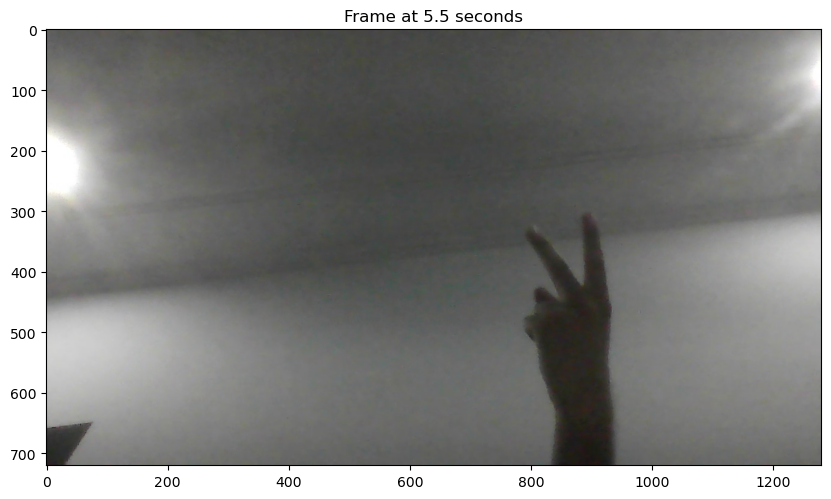

In [6]:
timestamp_seconds = 5.5 

timestamp_ms = timestamp_seconds * 1000
cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_ms)

ret, frame = cap.read()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.title(f"Frame at {timestamp_seconds} seconds")
    plt.axis('on') 
    plt.show()
else:
    print("Could not find a frame at that timestamp. Check your video duration!")

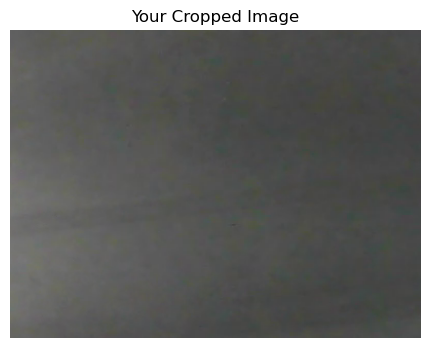

Success! Saved as 'final_crop.png'


In [7]:
ymin = 100   # Top edge
ymax = 400   # Bottom edge
xmin = 200   # Left edge
xmax = 600   # Right edge

cropped_frame = frame_rgb[ymin:ymax, xmin:xmax]

plt.figure(figsize=(6, 4))
plt.imshow(cropped_frame)
plt.title("Your Cropped Image")
plt.axis('off') 
plt.show()

final_bgr = cv2.cvtColor(cropped_frame, cv2.COLOR_RGB2BGR)
cv2.imwrite("final_crop.png", final_bgr)

print("Success! Saved as 'final_crop.png'")

cap.release()

In [18]:
video_path = input("Video filename: ")
timestamp_seconds = float(input("Timestamp (seconds): "))

ymin = int(input("Top boundary (ymin): "))
ymax = int(input("Bottom boundary (ymax): "))
xmin = int(input("Left boundary (xmin): "))
xmax = int(input("Right boundary (xmax): "))

output_filename = input("Output filename: ")

Video filename:  WIN_20260613_21_50_32_Pro
Timestamp (seconds):  4
Top boundary (ymin):  44
Bottom boundary (ymax):  44
Left boundary (xmin):  44
Right boundary (xmax):  44
Output filename:  task2file.jpg


In [19]:
import cv2

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video file.")
else:
    timestamp_ms = timestamp_seconds * 1000
    cap.set(cv2.CAP_PROP_POS_MSEC, timestamp_ms)
    
    ret, frame = cap.read()
    
    if ret:
        h, w, _ = frame.shape
        print(f"Original Video Size is: Width={w}, Height={h}")
        ymin_safe = max(0, min(ymin, h-1))
        ymax_safe = max(ymin_safe + 1, min(ymax, h))
        xmin_safe = max(0, min(xmin, w-1))
        xmax_safe = max(xmin_safe + 1, min(xmax, w))
        
        cropped_frame = frame[ymin_safe:ymax_safe, xmin_safe:xmax_safe]
        print(f"Cropped Image Size: Width={cropped_frame.shape[1]}, Height={cropped_frame.shape[0]}")
    else:
        print("Error: Could not read frame at this timestamp.")

Error: Could not open video file.


Saved as task2file.jpg


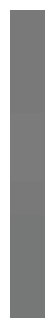

In [20]:
import matplotlib.pyplot as plt

if 'cropped_frame' in locals() and cropped_frame.size > 0:
    cv2.imwrite(output_filename, cropped_frame)
    print(f"Saved as {output_filename}")

    preview_rgb = cv2.cvtColor(cropped_frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 4))
    plt.imshow(preview_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Error: Crop data is empty. Re-check your input coordinates in Cell 1.")

cap.release()